# Lower Quality dataset

## Imports

In [3]:
import json
from datasets import load_dataset
from collections import Counter
import matplotlib.pyplot as plt
import statistics
import numpy as np
import re
import random
import pandas as pd





# STEP 1 - DATA LOADING

In [4]:
dataset = load_dataset(
    "togethercomputer/RedPajama-Data-V2",
    name="sample",
    languages=["en"],
    split="train",
    streaming=True
)

dataset = list(dataset.take(5000))

print(f"Number of documents: {len(dataset)}")
print(f"Keys: {dataset[0].keys()}")
print()
print("--- Example document ---")
print(dataset[0]["raw_content"][:500])

Number of documents: 5000
Keys: dict_keys(['raw_content', 'doc_id', 'meta', 'quality_signals'])

--- Example document ---
Abierto el plazo para participar en la Noche Europea de los Investigadores 2017
admin 18 abril, 2017 Abierto el plazo para participar en la Noche Europea de los Investigadores 20172017-04-18T08:57:48+01:00 Actividades
Por séptimo año consecutivo la Universidad de Sevilla participa en la Noche Europea de los Investigadores. Una actividad de divulgación científica que se celebrará el viernes 29 de septiembre en más de 300 ciudades europeas de manera simultánea. En la Noche Europea de los Investiga


In [5]:
language_scores = []
languages_detected = []

for doc in dataset:
    qs = json.loads(doc["quality_signals"])
    lang_score = qs["ccnet_language_score"][0][2]
    language_scores.append(lang_score)
    # meta contains the detected language
    meta = json.loads(doc["meta"]) if isinstance(doc["meta"], str) else doc["meta"]
    languages_detected.append(meta.get("language", "unknown"))

lang_counts = Counter(languages_detected)
print("Language distribution:")
for lang, count in lang_counts.most_common(10):
    print(f"  {lang}: {count} documents ({100*count/len(dataset):.1f}%)")

print(f"\nAverage language confidence score: {sum(language_scores)/len(language_scores):.3f}")

Language distribution:
  es: 5000 documents (100.0%)

Average language confidence score: 0.958


Može se primetiti da su svi dokumenti na španskom jeziku, iako sam u prvoj ćeliji postavio „en“ kao oznaku za jezik. Ovo je savršen primer iz stvarnog sveta za problem identifikacije jezika.

## Reload

In [6]:
from datasets import load_dataset
import json

ds = load_dataset(
    "togethercomputer/RedPajama-Data-V2",
    name="default",
    partition="head_middle",
    snapshots=["2023-06"],
    languages=["en"],
    streaming=True
)

def fails_quality_filter(doc):
    qs = json.loads(doc["quality_signals"])
    word_count = qs["rps_doc_word_count"][0][2]
    if word_count < 50 or word_count > 100_000:
        return True
    mean_word_length = qs["rps_doc_mean_word_length"][0][2]
    if mean_word_length < 3 or mean_word_length > 10:
        return True
    symbol_ratio = qs["rps_doc_symbol_to_word_ratio"][0][2]
    if symbol_ratio > 0.1:
        return True
    stop_word_fraction = qs["rps_doc_stop_word_fraction"][0][2]
    if stop_word_fraction < 0.1:
        return True
    top_2gram = qs["rps_doc_frac_chars_top_2gram"][0][2]
    if top_2gram > 0.2:
        return True
    return False

dataset = []
for doc in ds["train"]:
    if fails_quality_filter(doc):
        dataset.append(doc)
    if len(dataset) == 5000:
        break

print(f"Low-quality documents collected: {len(dataset)}")

Low-quality documents collected: 5000


In [7]:
language_scores = []
languages_detected = []

for doc in dataset:
    qs = json.loads(doc["quality_signals"])
    lang_score = qs["ccnet_language_score"][0][2]
    language_scores.append(lang_score)
    meta = json.loads(doc["meta"]) if isinstance(doc["meta"], str) else doc["meta"]
    languages_detected.append(meta.get("language", "unknown"))

lang_counts = Counter(languages_detected)
print("Language distribution:")
for lang, count in lang_counts.most_common(10):
    print(f"  {lang}: {count} documents ({100 * count / len(dataset):.1f}%)")

print(f"\nAverage language confidence score: {sum(language_scores) / len(language_scores):.3f}")


Language distribution:
  en: 5000 documents (100.0%)

Average language confidence score: 0.811


# STEP 2 - BASIC EXPLORATION

Total documents: 5000
Average length:  1441 characters
Median length:   159 characters
Shortest: 4 characters
Longest:  959380 characters

Documents under 100 chars:  1742
Documents over 100k chars:  7


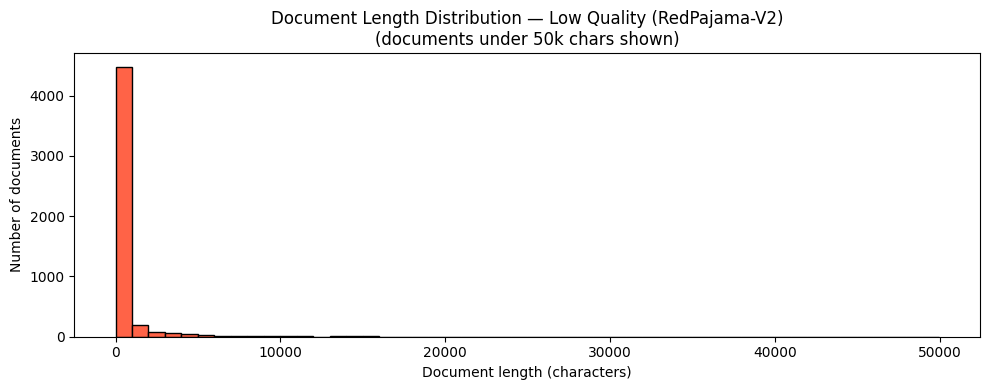

In [8]:
lengths = [len(doc["raw_content"]) for doc in dataset]

print(f"Total documents: {len(lengths)}")
print(f"Average length:  {sum(lengths)/len(lengths):.0f} characters")
print(f"Median length:   {statistics.median(lengths):.0f} characters")
print(f"Shortest: {min(lengths)} characters")
print(f"Longest:  {max(lengths)} characters")
print(f"\nDocuments under 100 chars:  {sum(1 for l in lengths if l < 100)}")
print(f"Documents over 100k chars:  {sum(1 for l in lengths if l > 100_000)}")

filtered_lengths = [l for l in lengths if l < 50_000]
plt.figure(figsize=(10, 4))
plt.hist(filtered_lengths, bins=50, color="tomato", edgecolor="black")
plt.title("Document Length Distribution — Low Quality (RedPajama-V2)\n(documents under 50k chars shown)")
plt.xlabel("Document length (characters)")
plt.ylabel("Number of documents")
plt.tight_layout()
plt.show()

In [9]:
print(f"Keys: {dataset[0].keys()}")
print()
print("--- Example document ---")
print(dataset[0]["raw_content"][:500])

Keys: dict_keys(['raw_content', 'doc_id', 'meta', 'quality_signals'])

--- Example document ---
Banc Texas Allen Parkway, completed 1983
Banc Texas Allen Parkway, completed 1983, Box: 6, Folder: 4. Arthur E. Jones Architectural Records, MS 535. Woodson Research Center, Rice University, Houston, Texas. http://archives.library.rice.edu/repositories/2/archival_objects/79290 Accessed January 26, 2023.


Failure reasons (documents can fail multiple rules):
  too few words (<50): 4167 documents (83.3%)
  low stop-word fraction: 2034 documents (40.7%)
  repetitive 2-grams: 452 documents (9.0%)
  mean word length >10: 313 documents (6.3%)
  mean word length <3: 115 documents (2.3%)
  high symbol ratio: 63 documents (1.3%)
  too many words (>100k): 4 documents (0.1%)


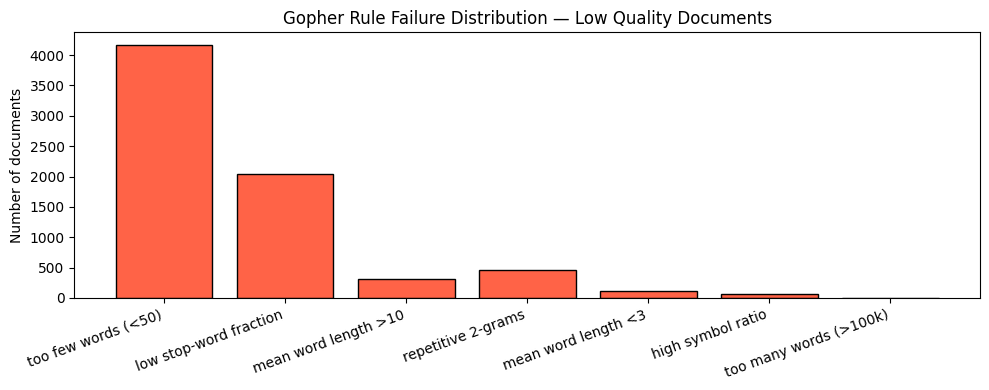

In [10]:
failure_reasons = []

for doc in dataset:
    qs = json.loads(doc["quality_signals"])
    reasons = []
    word_count = qs["rps_doc_word_count"][0][2]
    if word_count < 50:
        reasons.append("too few words (<50)")
    if word_count > 100_000:
        reasons.append("too many words (>100k)")
    if qs["rps_doc_mean_word_length"][0][2] < 3:
        reasons.append("mean word length <3")
    if qs["rps_doc_mean_word_length"][0][2] > 10:
        reasons.append("mean word length >10")
    if qs["rps_doc_symbol_to_word_ratio"][0][2] > 0.1:
        reasons.append("high symbol ratio")
    if qs["rps_doc_stop_word_fraction"][0][2] < 0.1:
        reasons.append("low stop-word fraction")
    if qs["rps_doc_frac_chars_top_2gram"][0][2] > 0.2:
        reasons.append("repetitive 2-grams")
    failure_reasons.extend(reasons)

reason_counts = Counter(failure_reasons)
print("Failure reasons (documents can fail multiple rules):")
for reason, count in reason_counts.most_common():
    print(f"  {reason}: {count} documents ({100*count/len(dataset):.1f}%)")

plt.figure(figsize=(10, 4))
plt.bar(reason_counts.keys(), reason_counts.values(), color="tomato", edgecolor="black")
plt.title("Gopher Rule Failure Distribution — Low Quality Documents")
plt.ylabel("Number of documents")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Grafikon prikazuje razloge zbog kojih dokumenti nisu ispunili Gopher pravila. Većina je odbačena jer su sadržali premalo reči (<50), što ukazuje na to da se veliki deo ovog korpusa sastoji od fragmenata, a ne od celovitih dokumenata. Gotovo polovina takođe nije zadovoljila prag udela stop-reči (stop-words), što sugeriše da tim dokumentima nedostaje prirodna lingvistička struktura tipična za tečan tekst.

Statistika dužine potvrđuje nizak kvalitet ovog skupa podataka: medijana dužine dokumenta iznosi svega 159 karaktera, dok je prosek 1.441 – što je jaz uzrokovan sa samo 7 dokumenata koji premašuju 100.000 karaktera, čime značajno podižu prosek. Pored toga, samo 4 dokumenta su premašila 100.000 reči, što znači da se filter za broj reči retko aktivirao zbog prevelike dužine – većina neuspeha bila je na donjoj granici (premalo reči).

In [11]:
qs = json.loads(dataset[0]["quality_signals"])

print("Quality signals for document 0:")
for key, value in qs.items():
    print(f"  {key}: {value}")

Quality signals for document 0:
  ccnet_length: [[0, 304, 304.0]]
  ccnet_original_length: [[0, 304, 2736.0]]
  ccnet_nlines: [[0, 304, 2.0]]
  ccnet_original_nlines: [[0, 304, 67.0]]
  ccnet_language_score: [[0, 304, 0.82]]
  ccnet_perplexity: [[0, 304, 333.4]]
  ccnet_bucket: [[0, 304, 0.0]]
  rps_doc_curly_bracket: [[0, 304, 0.0]]
  rps_doc_ldnoobw_words: [[0, 304, 0.0]]
  rps_doc_lorem_ipsum: [[0, 304, 0.0]]
  rps_doc_stop_word_fraction: [[0, 304, 0.01492537]]
  rps_doc_ut1_blacklist: [[0, 304, None]]
  rps_doc_frac_chars_dupe_10grams: [[0, 304, 0.0]]
  rps_doc_frac_chars_dupe_5grams: [[0, 304, 0.27983539]]
  rps_doc_frac_chars_dupe_6grams: [[0, 304, 0.27983539]]
  rps_doc_frac_chars_dupe_7grams: [[0, 304, 0.0]]
  rps_doc_frac_chars_dupe_8grams: [[0, 304, 0.0]]
  rps_doc_frac_chars_dupe_9grams: [[0, 304, 0.0]]
  rps_doc_frac_chars_top_2gram: [[0, 304, 0.07407407]]
  rps_doc_frac_chars_top_3gram: [[0, 304, 0.11522634]]
  rps_doc_frac_chars_top_4gram: [[0, 304, 0.17283951]]
  rps_doc

ccnet_perplexity - 333.4 - Veoma visoka — haotičan, nepredvidiv tekst

ccnet_language_score - 0.82 - Ispodprosečna pouzdanost — na granici engleskog jezika

rps_doc_stop_word_fraction - 0.015 - Izuzetno niska — samo 1.5% stop-reči, znatno ispod praga od 0.1. Ovo je razlog zašto nije ispunio Gopher kriterijume

rps_doc_word_count - Samo 35 reči — daleko ispod minimuma od 50 reči

rps_doc_frac_no_alph_words - 0.493 - Skoro 50% reči ne sadrži nijedno slovo alfabeta — tipično za tabele, liste ili metapodatke

rps_doc_frac_chars_dupe_5grams - 0.280 - 28% karaktera se nalazi u ponovljenim 5-gramima — značajno ponavljanje

ccnet_original_length and ccnet_length - 2736 vs 304 - Dokument je prvobitno bio 9 puta duži — CCNet je uklonio 88% sadržaja kao duplirane redove

rps_doc_ml_palm_score - 0.001 - Blizu nule — klasifikator ocenjuje ovaj tekst izuzetno niskim kvalitetom

-------------

CCNet je pipeline koja je obradila sirove CommonCrawl podatke pre nego što su ušli u RedPajama skup. On vrši identifikaciju jezika, deduplikaciju na nivou redova, racuna perpleksnost koristeći mali jezički model obučen na Vikipediji, i razvrstava svaki dokument u kategorije kvaliteta (head/middle/tail) isključivo na osnovu perpleksnosti.

Kao što pokazuje dokument 0 — koji je CCNet označio kao vrhunski kvalitet (bucket 0.0), ali ga je Gopher odbacio zbog samo 35 reči i udela stop-reči od 0,015 — nijedan pojedinačni filter sam po sebi nije dovoljan.

# STEP3 - LEXICAL ANALYSIS

## TTR

Average TTR: 0.828
Median TTR:  0.875
Min TTR:     0.003
Max TTR:     1.000


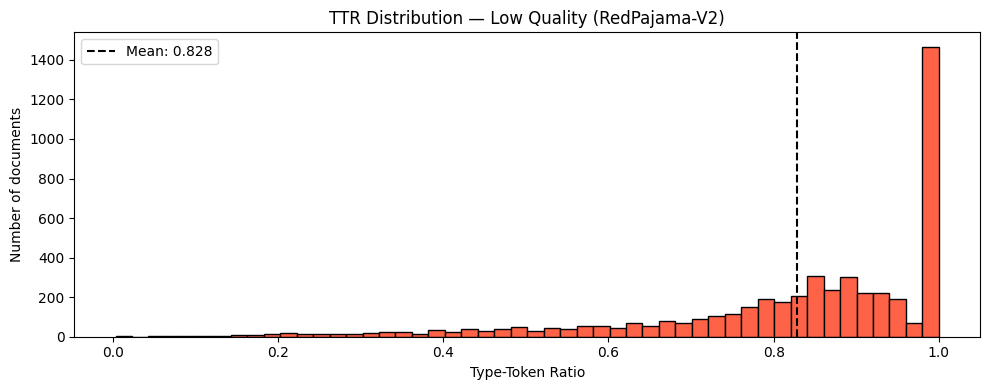

In [12]:
ttr_scores = []

for doc in dataset:
    words = doc["raw_content"].lower().split()
    if len(words) == 0:
        continue
    ttr = len(set(words)) / len(words)
    ttr_scores.append(ttr)

print(f"Average TTR: {np.mean(ttr_scores):.3f}")
print(f"Median TTR:  {np.median(ttr_scores):.3f}")
print(f"Min TTR:     {min(ttr_scores):.3f}")
print(f"Max TTR:     {max(ttr_scores):.3f}")

plt.figure(figsize=(10, 4))
plt.hist(ttr_scores, bins=50, color="tomato", edgecolor="black")
plt.title("TTR Distribution — Low Quality (RedPajama-V2)")
plt.xlabel("Type-Token Ratio")
plt.ylabel("Number of documents")
plt.axvline(np.mean(ttr_scores), color="black", linestyle="--", label=f"Mean: {np.mean(ttr_scores):.3f}")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
lengths = [len(doc["raw_content"].split()) for doc in dataset]
correlation = np.corrcoef(lengths, ttr_scores)[0, 1]
print(f"Correlation between document length and TTR: {correlation:.3f}")

Correlation between document length and TTR: -0.162


In [14]:
buckets = {"very short (0-50 words)": [],
           "short (50-200 words)": [],
           "medium (200-500 words)": [],
           "long (500+ words)": []}

for length, ttr in zip(lengths, ttr_scores):
    if length < 50:
        buckets["very short (0-50 words)"].append(ttr)
    elif length < 200:
        buckets["short (50-200 words)"].append(ttr)
    elif length < 500:
        buckets["medium (200-500 words)"].append(ttr)
    else:
        buckets["long (500+ words)"].append(ttr)

for bucket, ttrs in buckets.items():
    if ttrs:
        print(f"{bucket}: {len(ttrs)} docs, avg TTR = {np.mean(ttrs):.3f}")

very short (0-50 words): 4132 docs, avg TTR = 0.885
short (50-200 words): 439 docs, avg TTR = 0.664
medium (200-500 words): 213 docs, avg TTR = 0.509
long (500+ words): 216 docs, avg TTR = 0.376


Prosečna TTR vrednost je visoka (0.828), što sugeriše da, u proseku, dokumenti sadrže veliki udeo jedinstvenih reči. Međutim, ova metrika nije reprezentativan s obzirom na izuzetno malu dužinu većine dokumenata (medijan = 159 karaktera, ~25 reči). Što manje reči dokument sadrži, to je veća verovatnoća da će svaka reč biti jedinstvena, što veštački uvećava TTR skor. Kao što se i očekivalo, kada se dokumenti grupišu po dužini, pojavljuje se jasna inverzna veza — što dokument sadrži više reči, to je njegov TTR niži, što je u skladu sa teorijskim ograničenjima.

In [15]:
all_words = []
for doc in dataset:
    words = doc["raw_content"].lower().split()
    all_words.extend(words)

word_counts = Counter(all_words)

print(f"Total tokens:       {len(all_words)}")
print(f"Unique tokens:      {len(word_counts)}")
print(f"Global TTR:         {len(word_counts)/len(all_words):.3f}")
print(f"\nTop 20 most frequent words:")
for word, count in word_counts.most_common(20):
    print(f"  '{word}': {count}")

Total tokens:       1023351
Unique tokens:      113034
Global TTR:         0.110

Top 20 most frequent words:
  'the': 28980
  'of': 24114
  'and': 22792
  'to': 16349
  'a': 13608
  'in': 13475
  '-': 7816
  'for': 7458
  'on': 7083
  'is': 6387
  '0': 6268
  'you': 5899
  'are': 4989
  'vol.': 4895
  'that': 4338
  'online': 4326
  'with': 4091
  'a.,': 4015
  'm.,': 3871
  'as': 3776


Globalni TTR na nivou korpusa od 0,110 je reprezentativniji od proseka po pojedinačnim dokumentima, jer odražava prirodno ponavljanje reči kroz 1.023.351 tokena. Ova niska vrednost ukazuje na ograničenu raznolikost rečnika u celokupnom korpusu.

Analiza 20 najučestalijih reči otkriva jasne probleme s kvalitetom. Iako su vodeće stavke uobičajene engleske stop-reči, izdvaja se nekoliko anomalija: samostalna crtica '-' (7.816 pojavljivanja), cifra '0' (6.268 pojavljivanja), i naročito 'vol.', 'a.,' i 'm.,' - fragmenti tipični za liste akademskih citata. Ovi tokeni direktno ilustruju problem kontaminacije šablona (boilerplate). To takođe objašnjava nizak udeo stop-reči i visok udeo reči koje ne sadrže slova, što je primećeno u Koraku 2.

Visoka učestalost samostalne cifre '0' sugeriše ili obiman numerički sadržaj ili artefakte tokenizacije, gde se brojevi i simboli dele na pojedinačne karaktere, što je u skladu sa problemima tokenizacije.

## Zipf's law

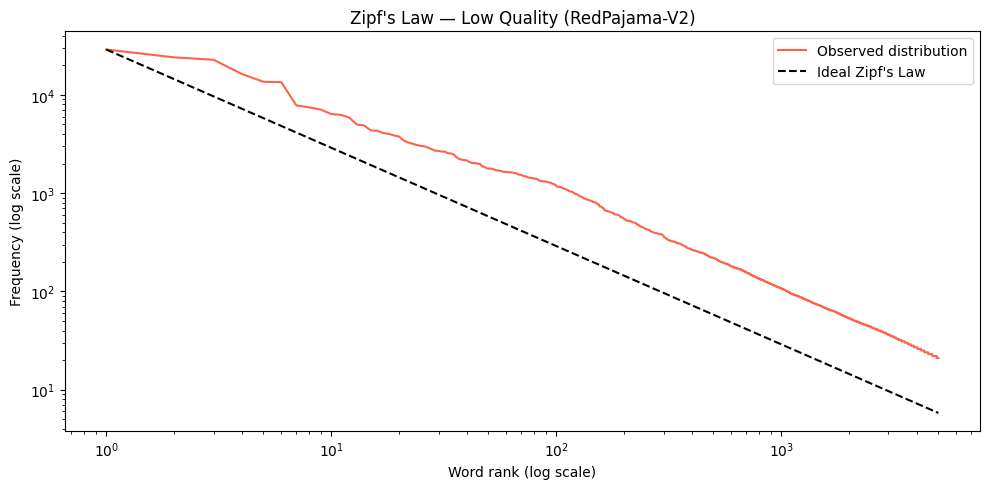

In [16]:
frequencies = sorted(word_counts.values(), reverse=True)
ranks = range(1, len(frequencies) + 1)

top_n = 5000
plt.figure(figsize=(10, 5))
plt.loglog(list(ranks)[:top_n], frequencies[:top_n],
           color="tomato", label="Observed distribution")

ideal_zipf = [frequencies[0] / r for r in ranks[:top_n]]
plt.loglog(list(ranks)[:top_n], ideal_zipf,
           color="black", linestyle="--", label="Ideal Zipf's Law")

plt.title("Zipf's Law — Low Quality (RedPajama-V2)")
plt.xlabel("Word rank (log scale)")
plt.ylabel("Frequency (log scale)")
plt.legend()
plt.tight_layout()
plt.show()

Grafikon otkriva značajna odstupanja od idealne distribucije (isprekidana linija), od kojih svako odgovara različitom problemu kvaliteta:

Na najvišim rangovima (leva strana), uočena učestalost je znatno veća od idealne, što ukazuje na to da se najčešće reči pojavljuju prekomerno — što je u skladu sa ponavljanjem boilerplate-a kroz dokumente. Medjutim, uočena linija ostaje iznad idealne i kroz srednje i krajnje rangove, što znači da se retke reči pojavljuju daleko češće nego što prirodni jezik predviđa. Ovo je karakteristično za "šum" među tokenima — fragmente interpunkcije, cifre i nepravilno formirane tokene — koji veštački naduvavaju krajnji deo rečnika.

Zajedno, ova odstupanja potvrđuju da ovom korpusu nedostaje prirodna lingvistička struktura koju bi dobro formiran skup podataka za obuku trebalo da poseduje.

Average unigram entropy:                  2.857
Average word count:                       201.8
Median word count:                        25.0


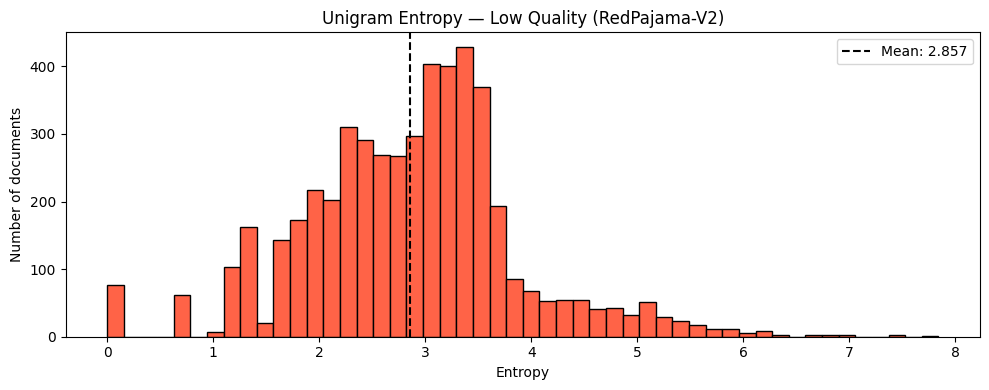

In [17]:
unigram_entropies = []
word_counts_qs = []

for doc in dataset:
    qs = json.loads(doc["quality_signals"])
    unigram_entropies.append(qs["rps_doc_unigram_entropy"][0][2])
    word_counts_qs.append(qs["rps_doc_word_count"][0][2])

print(f"Average unigram entropy:                  {np.mean(unigram_entropies):.3f}")
print(f"Average word count:                       {np.mean(word_counts_qs):.1f}")
print(f"Median word count:                        {np.median(word_counts_qs):.1f}")


plt.figure(figsize=(10, 4))

plt.hist(unigram_entropies, bins=50, color="tomato", edgecolor="black")
plt.title("Unigram Entropy — Low Quality (RedPajama-V2)")
plt.xlabel("Entropy")
plt.ylabel("Number of documents")
plt.axvline(np.mean(unigram_entropies), color="black", linestyle="--",
            label=f"Mean: {np.mean(unigram_entropies):.3f}")
plt.legend()
plt.tight_layout()
plt.show()


In [18]:
one_word_docs = [doc for doc in dataset if len(doc["raw_content"].split()) == 1]
print(f"Documents with only one word: {len(one_word_docs)}")
print("\nExamples:")
for doc in one_word_docs[:10]:
    qs = json.loads(doc["quality_signals"])
    entropy = qs["rps_doc_unigram_entropy"][0][2]
    print(f"  '{doc['raw_content'][:50]}' → entropy: {entropy}")

Documents with only one word: 73

Examples:
  '18_01_b' → entropy: 0.0
  'https://puppy-stork.com/Pueblo' → entropy: 0.0
  'naxalbari-covid-and-leftism' → entropy: 0.0
  'WS_1411-08' → entropy: 0.0
  'health-insurance-new-york' → entropy: 0.0
  '00:0000:0500:1000:1500:2000:2500:3000:3500:4000:45' → entropy: 0.0
  'how-to-build-a-relationship-with-people-ditch-the-' → entropy: 0.0
  '[2022-10]' → entropy: 0.0
  'https://www.blurb.com/user/roadgrill7' → entropy: 0.0
  'https://www.instagram.com/p/BXiXHDMh5l9/' → entropy: 0.0


Distribucija unigramske entropije ima prosek od 2.857, što je značajno ispod opsega od 5–7 koji je tipičan za visokokvalitetne korpuse prirodnog jezika. Ovo potvrđuje ograničenu raznolikost rečnika u celom skupu podataka.

Posebno se ističu 73 dokumenta koja imaju nultu ili gotovo nultu entropiju — to su ekstremni slučajevi u kojima se dokument sastoji skoro isključivo od jedne reči ili simbola koji se ponavlja, što predstavlja najteži oblik lingvističkog osiromašenja.

Jaz između prosečnog broja reči (201.8) i medijana (25.0) preslikava distribuciju dužine karaktera, čime se dodatno potvrđuje da korpusom dominiraju veoma kratki fragmenti, uz mali broj ekstremnih primera (outliers) koji značajno podižu prosek.

# STEP4 - Noise Detection

## HTML Tags

In [19]:
html_tag_pattern = re.compile(r'<[^>]+>')
nbsp_pattern = re.compile(r'&nbsp;')
html_entity_pattern = re.compile(r'&[a-z]+;')

html_counts = []
nbsp_counts = []
entity_counts = []

for doc in dataset:
    text = doc["raw_content"]
    html_counts.append(len(html_tag_pattern.findall(text)))
    nbsp_counts.append(len(nbsp_pattern.findall(text)))
    entity_counts.append(len(html_entity_pattern.findall(text)))

print(f"Documents with HTML tags:     {sum(1 for c in html_counts if c > 0)} ({100*sum(1 for c in html_counts if c > 0)/len(dataset):.1f}%)")
print(f"Documents with &nbsp;:        {sum(1 for c in nbsp_counts if c > 0)} ({100*sum(1 for c in nbsp_counts if c > 0)/len(dataset):.1f}%)")
print(f"Documents with HTML entities: {sum(1 for c in entity_counts if c > 0)} ({100*sum(1 for c in entity_counts if c > 0)/len(dataset):.1f}%)")
print(f"\nAverage HTML tags per document:     {sum(html_counts)/len(html_counts):.2f}")
print(f"Average &nbsp; per document:        {sum(nbsp_counts)/len(nbsp_counts):.2f}")
print(f"Average HTML entities per document: {sum(entity_counts)/len(entity_counts):.2f}")

for doc in dataset:
    if html_tag_pattern.search(doc["raw_content"]):
        print(f"\n--- Example document with HTML tags ---")
        print(doc["raw_content"][:500])
        break

Documents with HTML tags:     32 (0.6%)
Documents with &nbsp;:        2 (0.0%)
Documents with HTML entities: 6 (0.1%)

Average HTML tags per document:     0.07
Average &nbsp; per document:        0.00
Average HTML entities per document: 0.03

--- Example document with HTML tags ---
37 Maddona-compressed
<span class="attachment-meta">Published on <time class="entry-date" datetime="2016-07-28T18:35:13+00:00">July 28, 2016</time> in <a href="http://rajulmehta.com/gallery/ripples-of-body-and-soul/" title="Return to Ripples of Body and Soul" rel="gallery">Ripples of Body and Soul</a></span>Full resolution (962 × 1200)


Samo 0.6% dokumenata sadrži preostale HTML tagove, što je i očekivano — CCNet je već izvršio uklanjanje HTML-a (HTML stripping) kao deo svog preprocessinga pre nego što su podaci ušli u RedPajama skup.

## Boilerplate tags

Average symbol-to-word ratio:      0.006
Average non-alphabetical fraction: 0.359
Documents with curly brackets:     17 (0.3%)
Documents with JavaScript:         7 (0.1%)


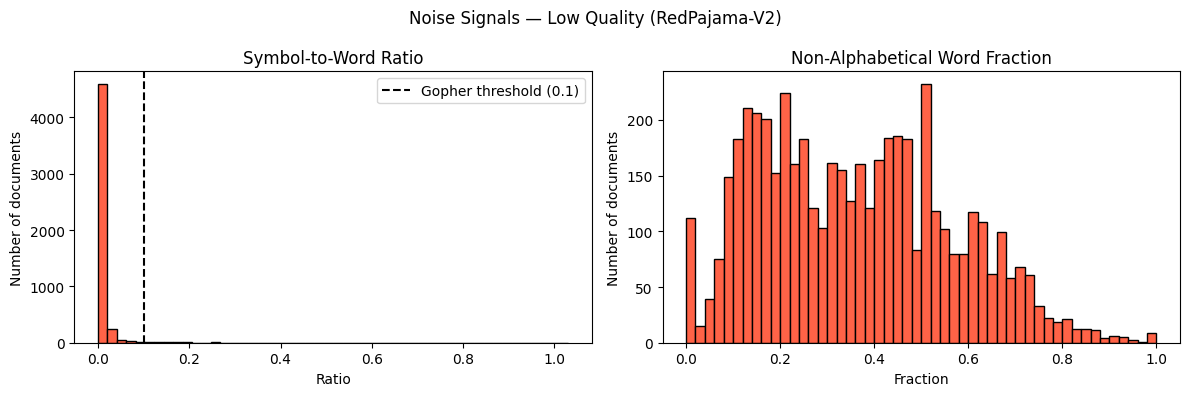

In [20]:
symbol_ratios = []
no_alph_fractions = []
curly_bracket_ratios = []
javascript_counts = []

for doc in dataset:
    qs = json.loads(doc["quality_signals"])
    symbol_ratios.append(qs["rps_doc_symbol_to_word_ratio"][0][2])
    no_alph_fractions.append(qs["rps_doc_frac_no_alph_words"][0][2])
    curly_bracket_ratios.append(qs["rps_doc_curly_bracket"][0][2])
    js = sum(line[2] for line in qs["rps_lines_javascript_counts"])
    javascript_counts.append(js)

print(f"Average symbol-to-word ratio:      {np.mean(symbol_ratios):.3f}")
print(f"Average non-alphabetical fraction: {np.mean(no_alph_fractions):.3f}")
print(f"Documents with curly brackets:     {sum(1 for c in curly_bracket_ratios if c > 0)} ({100*sum(1 for c in curly_bracket_ratios if c > 0)/len(dataset):.1f}%)")
print(f"Documents with JavaScript:         {sum(1 for c in javascript_counts if c > 0)} ({100*sum(1 for c in javascript_counts if c > 0)/len(dataset):.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(symbol_ratios, bins=50, color="tomato", edgecolor="black")
axes[0].set_title("Symbol-to-Word Ratio")
axes[0].set_xlabel("Ratio")
axes[0].set_ylabel("Number of documents")
axes[0].axvline(0.1, color="black", linestyle="--", label="Gopher threshold (0.1)")
axes[0].legend()

axes[1].hist(no_alph_fractions, bins=50, color="tomato", edgecolor="black")
axes[1].set_title("Non-Alphabetical Word Fraction")
axes[1].set_xlabel("Fraction")
axes[1].set_ylabel("Number of documents")

plt.suptitle("Noise Signals — Low Quality (RedPajama-V2)")
plt.tight_layout()
plt.show()

Prosečan udeo simbola u odnosu na reči je nizak (0.006), a veoma mali broj dokumenata sadrži vitičaste zagrade (0.3%) ili JavaScript (0.1%), što odražava činjenicu da je CCNet već ranije u lancu obrade uklonio većinu tehničkih artefakata.

Međutim, udeo reči koje ne sadrže slova otkriva značajniji problem. Sa prosekom od 0.359, više od jedne trećine reči u celom korpusu ne sadrži nijedan karakter alfabeta. Distribucija pokazuje dva jasna vrha — jedan oko 0.15–0.20 (umereni šum) i drugi oko 0.50 (ozbiljan šum) — što ukazuje na to da se veliki podskup dokumenata sastoji od otprilike polovine netekstualnih tokena kao što su cifre, kodovi, fragmenti interpunkcije i URL-ovi. Gopher-ovo pravilo o udelu simbola ne hvata ovu vrstu šuma, što pokazuje da različiti metrici detektuju različite probleme i da nijedan pojedinačni signal nije dovoljan.

In [21]:
boilerplate_patterns = {
    "lorem ipsum": re.compile(r'lorem ipsum', re.IGNORECASE),
    "cookie notice": re.compile(r'cookie(s)?(\s+\w+)?\s+(policy|notice|consent)', re.IGNORECASE),
    "all rights reserved": re.compile(r'all rights reserved', re.IGNORECASE),
    "privacy policy": re.compile(r'privacy policy', re.IGNORECASE),
    "terms of service": re.compile(r'terms of (service|use)', re.IGNORECASE),
    "navigation menu": re.compile(r'(home\s*\|\s*about|home\s*\|\s*contact|menu\s*\|\s*home)', re.IGNORECASE),
}

boilerplate_counts = {key: 0 for key in boilerplate_patterns}

for doc in dataset:
    text = doc["raw_content"]
    for name, pattern in boilerplate_patterns.items():
        if pattern.search(text):
            boilerplate_counts[name] += 1

print("Boilerplate pattern detection:")
for pattern, count in sorted(boilerplate_counts.items(), key=lambda x: -x[1]):
    print(f"  {pattern}: {count} documents ({100*count/len(dataset):.1f}%)")

Boilerplate pattern detection:
  all rights reserved: 29 documents (0.6%)
  privacy policy: 17 documents (0.3%)
  terms of service: 10 documents (0.2%)
  lorem ipsum: 4 documents (0.1%)
  cookie notice: 1 documents (0.0%)
  navigation menu: 0 documents (0.0%)


Detekcija šablona otkriva da je CCNet-ovo prethodno čišćenje uklonilo većinu ponavljajućih veb elemenata. Međutim, pravni i autorski fragmenti su ipak opstali — „all rights reserved“ (29 dokumenata), „privacy policy“ (17 dokumenata) i „terms of service“ (10 dokumenata) — što je u skladu sa problemom šablonskog teksta u podnožju stranica (footer boilerplate).

## N-Grams

Documents with dupe 5-grams  > 0.1: 663 (13.3%)
Documents with dupe 10-grams > 0.1: 199 (4.0%)
Documents with top 2-gram    > 0.2: 452 (9.0%)

Average dupe 5-gram fraction:  0.058
Average dupe 10-gram fraction: 0.017


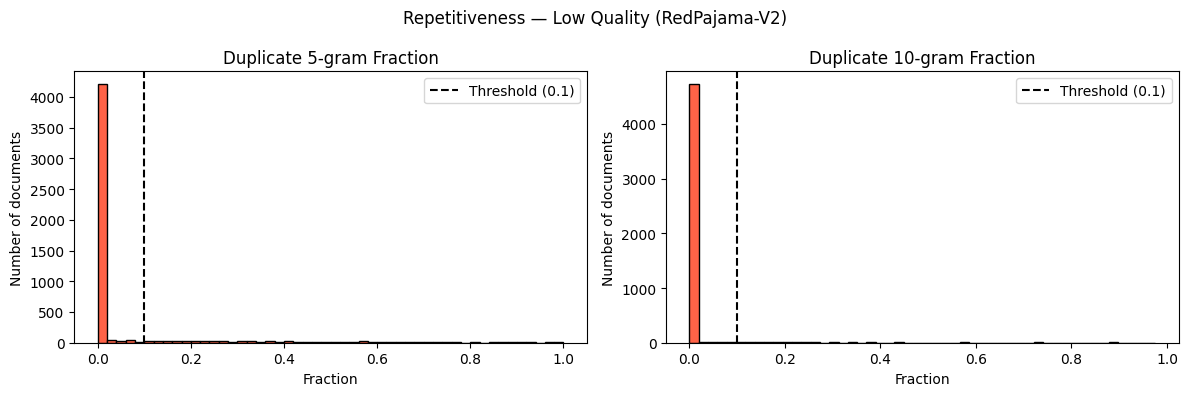

In [22]:
dupe_5gram = []
dupe_10gram = []
top_2gram = []

for doc in dataset:
    qs = json.loads(doc["quality_signals"])
    dupe_5gram.append(qs["rps_doc_frac_chars_dupe_5grams"][0][2])
    dupe_10gram.append(qs["rps_doc_frac_chars_dupe_10grams"][0][2])
    top_2gram.append(qs["rps_doc_frac_chars_top_2gram"][0][2])

print(f"Documents with dupe 5-grams  > 0.1: {sum(1 for x in dupe_5gram if x > 0.1)} ({100*sum(1 for x in dupe_5gram if x > 0.1)/len(dataset):.1f}%)")
print(f"Documents with dupe 10-grams > 0.1: {sum(1 for x in dupe_10gram if x > 0.1)} ({100*sum(1 for x in dupe_10gram if x > 0.1)/len(dataset):.1f}%)")
print(f"Documents with top 2-gram    > 0.2: {sum(1 for x in top_2gram if x > 0.2)} ({100*sum(1 for x in top_2gram if x > 0.2)/len(dataset):.1f}%)")
print(f"\nAverage dupe 5-gram fraction:  {np.mean(dupe_5gram):.3f}")
print(f"Average dupe 10-gram fraction: {np.mean(dupe_10gram):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(dupe_5gram, bins=50, color="tomato", edgecolor="black")
axes[0].set_title("Duplicate 5-gram Fraction")
axes[0].set_xlabel("Fraction")
axes[0].set_ylabel("Number of documents")
axes[0].axvline(0.1, color="black", linestyle="--", label="Threshold (0.1)")
axes[0].legend()

axes[1].hist(dupe_10gram, bins=50, color="tomato", edgecolor="black")
axes[1].set_title("Duplicate 10-gram Fraction")
axes[1].set_xlabel("Fraction")
axes[1].set_ylabel("Number of documents")
axes[1].axvline(0.1, color="black", linestyle="--", label="Threshold (0.1)")
axes[1].legend()

plt.suptitle("Repetitiveness — Low Quality (RedPajama-V2)")
plt.tight_layout()
plt.show()

Analiza ponavljanja pokazuje da 13.3% dokumenata premašuje prag od 0.1 za duplirane 5-grame, dok samo 4.0% premašuje taj prag za 10-grame. Ovakav obrazac je očekivan — ponavljanje kratkih fraza je češće od ponavljanja na nivou pasusa. Ovaj udeo predstavlja proporciju karaktera koji pripadaju sekvencama koje se ponavljaju; vrednost iznad 0.1 znači da se više od 10% sadržaja dokumenta ponavlja doslovno (verbatim).

Grafikoni potvrđuju da se većina dokumenata grupiše blizu nulte stope ponavljanja, ali se krajnji deo distribucije (tail) proteže sve do 1.0 za 5-grame — što znači da se neki dokumenti sastoje skoro isključivo od ponovljenih kratkih fraza. Ovi ekstremni slučajevi direktno ilustruju problem petlji ponavljanja (repetition loops), gde modeli obučeni na takvim podacima nauče da dodeljuju neproporcionalno visoku verovatnoću sekvencama koje se ponavljaju, što dovodi do toga da se zaglave generišući iste fraze tokom zaključivanja (inference).

# STEP5 - Deduplication

## Duplicates

In [23]:
duplicate_flags = []
for doc in dataset:
    qs = json.loads(doc["quality_signals"])
    duplicate_flags.append(qs["is_duplicate"])

total_duplicates = sum(duplicate_flags)
print(f"Total documents:    {len(dataset)}")
print(f"Exact duplicates:   {total_duplicates} ({100*total_duplicates/len(dataset):.1f}%)")
print(f"Unique documents:   {len(dataset) - total_duplicates} ({100*(len(dataset)-total_duplicates)/len(dataset):.1f}%)")

for doc in dataset:
    qs = json.loads(doc["quality_signals"])
    if qs["is_duplicate"]:
        print(f"\n--- Example duplicate document ---")
        print(doc["raw_content"][:300])
        break

Total documents:    5000
Exact duplicates:   636 (12.7%)
Unique documents:   4364 (87.3%)

--- Example duplicate document ---
No one is chatting at the moment.


Precizna deduplikacija (exact deduplication) otkriva da je 12.7% dokumenata (1 od 8) označeno kao duplikati — identične kopije drugih dokumenata u korpusu. Primer dokumenta „No one is chatting at the moment.“ je tipičan slučaj: boilerplate iz vidžeta za čet koji se pojavljuje identično na mnogo različitih veb-sajtova, a nosi nultu informativnu vrednost za obuku jezičkih modela.

## Jaccard similarity

Pre-calculating n-grams for 5000 documents...
Starting all-pairs comparison (12.5M pairs)...
Comparison complete in 17.51 seconds.
------------------------------
Total pairs compared: 11559497
Average Jaccard similarity: 0.000116
Near-duplicate pairs (> 0.5): 113
Near-duplicate pairs (> 0.8): 31


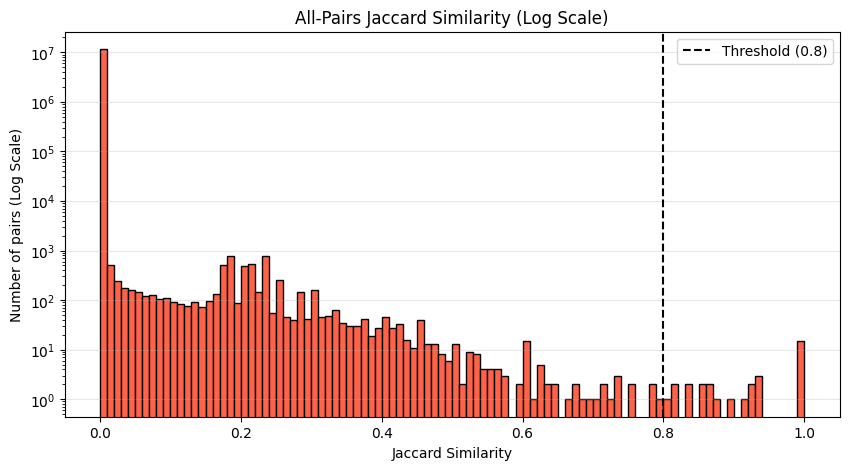

In [24]:
import time

def get_ngrams(text, n=5):
    words = text.lower().split()
    if len(words) < n:
        return set()
    return set(zip(*[words[i:] for i in range(n)]))

print(f"Pre-calculating n-grams for {len(dataset)} documents...")
start_time = time.time()
all_ngram_sets = [get_ngrams(doc["raw_content"], n=5) for doc in dataset]

jaccard_scores = []
near_duplicate_pairs = []
threshold_50 = 0.5
threshold_80 = 0.8

print("Starting all-pairs comparison (12.5M pairs)...")
num_docs = len(all_ngram_sets)

for i in range(num_docs):
    set_i = all_ngram_sets[i]
    if not set_i:
        continue

    for j in range(i + 1, num_docs):
        set_j = all_ngram_sets[j]

        intersection_len = len(set_i & set_j)

        if intersection_len == 0:
            jaccard_scores.append(0.0)
            continue

        union_len = len(set_i | set_j)
        score = intersection_len / union_len
        jaccard_scores.append(score)

        if score > threshold_50:
            near_duplicate_pairs.append((i, j, score))

end_time = time.time()
print(f"Comparison complete in {end_time - start_time:.2f} seconds.")


avg_sim = np.mean(jaccard_scores) if jaccard_scores else 0
count_80 = sum(1 for _, _, s in near_duplicate_pairs if s > 0.8)

print("-" * 30)
print(f"Total pairs compared: {len(jaccard_scores)}")
print(f"Average Jaccard similarity: {avg_sim:.6f}")
print(f"Near-duplicate pairs (> 0.5): {len(near_duplicate_pairs)}")
print(f"Near-duplicate pairs (> 0.8): {count_80}")

plt.figure(figsize=(10, 5))
plt.hist(jaccard_scores, bins=100, color="tomato", edgecolor="black", log=True) # Log scale helps see small counts
plt.title("All-Pairs Jaccard Similarity (Log Scale)")
plt.xlabel("Jaccard Similarity")
plt.ylabel("Number of pairs (Log Scale)")
plt.axvline(0.8, color="black", linestyle="--", label="Threshold (0.8)")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [25]:
top_3_pairs = sorted(near_duplicate_pairs, key=lambda x: x[2], reverse=True)[:3]

print("\n" + "="*50)
print(f"TOP 3 MOST SIMILAR PAIRS (Found {len(near_duplicate_pairs)} total matches > 0.5)")
print("="*50 + "\n")

if not top_3_pairs:
    print("No pairs found with similarity > 0.5.")
else:
    for rank, (idx1, idx2, score) in enumerate(top_3_pairs, 1):
        print(f"RANK {rank} | Jaccard Score: {score:.4f}")
        print("-" * 30)

        text1 = dataset[idx1]["raw_content"]
        text2 = dataset[idx2]["raw_content"]

        print(f"Document {idx1}: {text1[:300]}...")
        print(f"\nDocument {idx2}: {text2[:300]}...")
        print("\n" + "*"*50 + "\n")

exact_matches = [p for p in near_duplicate_pairs if p[2] >= 0.99]
print(f"Number of exact verbatim duplicates found: {len(exact_matches)}")


TOP 3 MOST SIMILAR PAIRS (Found 113 total matches > 0.5)

RANK 1 | Jaccard Score: 1.0000
------------------------------
Document 246: "1984" George Orwell
I read the novel "1984" by George Orwell. I wonder how many people know this dystopia from a quote about Big Brother's widespread surveillance, and who has read and remembers this entire work well? The second half is hell. The realism of violence and the......

Document 4369: "1984" George Orwell
I read the novel "1984" by George Orwell. I wonder how many people know this dystopia from a quote about Big Brother's widespread surveillance, and who has read and remembers this entire work well? The second half is hell. The realism of violence and the......

**************************************************

RANK 2 | Jaccard Score: 1.0000
------------------------------
Document 999: Ouch. It seems we can’t find what you’re looking for....

Document 4952: Ouch. It seems we can’t find what you’re looking for....

*************************

Skup podataka ima izuzetno nisku stopu doslovne redundanse (verbatim redundancy), sa samo 31 parom koji pokazuje skoro potpuno preklapanje. Iako bi smanjenje vrednosti ***n*** na 3 povećalo broj detektovanih redundantnih dokumenata, to bi takođe značajno povećalo broj lažno pozitivnih rezultata (false positives) zbog niske medijane broja reči (25). Pri ***n*** = 3, uobičajene kratke fraze bi verovatno bile označene kao „redundantne“ čak i ako su dokumenti kontekstualno jedinstveni.

Takođe, može se primetiti da je broj duplikata dobijenih pomoću Džakardovih (Jaccard) metrika znatno manji od broja onih koji su dobijeni putem oznake „is_duplicate“.

Total Flags Analyzed: 636
------------------------------
Average Word Count: 87.6
Median Word Count:  22.0
Documents with < 5 words: 52

--- SAMPLE OF FLAGGED DUPLICATES ---
   word_count                                               text
0           7                  No one is chatting at the moment.
1          11  Contraception use as well as determinants out ...
2         571  Filters: Author is O. Hermansen [Clear All Fil...
3          14  You must be logged in to set this as a best an...
4           4                               Events in April 2021
5          42  WRAIR\nMHRP/WRAIR labs 2017\nWRAIR Laboratory ...
6           9  You do not have access to download this attach...
7         467  Filters: Author is Kristina V. Collins [Clear ...
8           9  1 towns and cities participating in Greece in ...
9          19  Wednesday, January 8 2020\nToronto Drop-in: Dr...


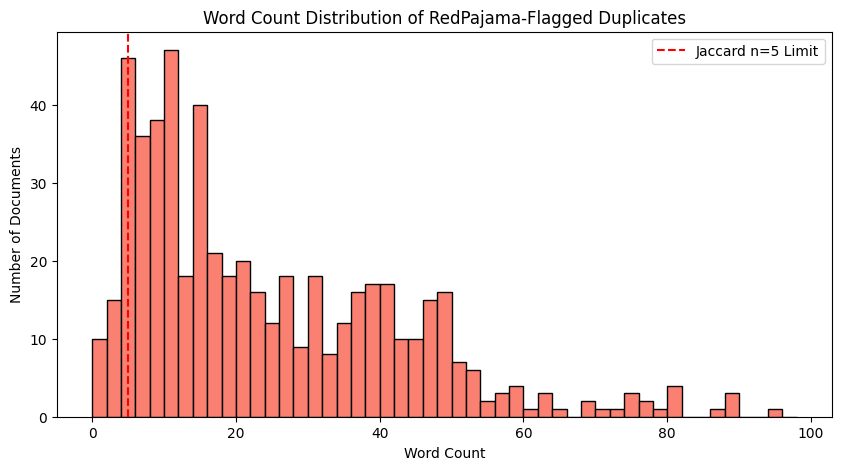

In [26]:
duplicates = [doc for doc in dataset if json.loads(doc["quality_signals"]).get("is_duplicate")]

duplicate_data = []
for doc in duplicates:
    text = doc["raw_content"]
    word_count = len(text.split())
    duplicate_data.append({
        "text": text[:100], # Preview
        "word_count": word_count,
        "is_jaccard_invisible": word_count < 5
    })

df_dupes = pd.DataFrame(duplicate_data)

print(f"Total Flags Analyzed: {len(df_dupes)}")
print("-" * 30)
print(f"Average Word Count: {df_dupes['word_count'].mean():.1f}")
print(f"Median Word Count:  {df_dupes['word_count'].median()}")
print(f"Documents with < 5 words: {df_dupes['is_jaccard_invisible'].sum()}")

print("\n--- SAMPLE OF FLAGGED DUPLICATES ---")
print(df_dupes[['word_count', 'text']].head(10))

plt.figure(figsize=(10, 5))
plt.hist(df_dupes['word_count'], bins=range(0, 100, 2), color="salmon", edgecolor="black")
plt.axvline(5, color="red", linestyle="--", label="Jaccard n=5 Limit")
plt.title("Word Count Distribution of RedPajama-Flagged Duplicates")
plt.xlabel("Word Count")
plt.ylabel("Number of Documents")
plt.legend()
plt.show()

Prvobitno sam sumnjao da je neslaganje između mojih Jaccard rezultata i „is_duplicate“ oznaka nastalo zbog toga što su kratki dokumenti (ispod 5 reči) nevidljivi za n-gram analizu. Međutim, podaci pokazuju da većina označenih duplikata zapravo premašuje 5 reči. Pravo objašnjenje leži u obimu poređenja: „is_duplicate“ oznaka je globalni metapodatak koji odražava redundansu u celom RedPajama korpusu (i širem vebu), dok 5-gram Jaccard metodologija detektuje redundansu samo lokalno, unutar mog uzorka od 5.000 dokumenata. Shodno tome, dokument može biti „globalni“ duplikat, dok istovremeno ostaje „lokalno“ jedinstven u mom podskupu.

## MinHash

In [27]:
from datasketch import MinHash, MinHashLSH

num_perm = 128
threshold = 0.8
n_gram_size = 5

def get_5gram_minhash(text, n=5, num_perm=128):
    m = MinHash(num_perm=num_perm)
    words = text.lower().split()
    if len(words) < n:
        return m

    for i in range(len(words) - n + 1):
        shingle = " ".join(words[i : i + n])
        m.update(shingle.encode('utf8'))
    return m

lsh = MinHashLSH(threshold=threshold, num_perm=num_perm)
minhashes = []

print(f"Generating 5-gram MinHashes for {len(dataset)} documents...")
for i, doc in enumerate(dataset):
    m = get_5gram_minhash(doc["raw_content"], n=n_gram_size, num_perm=num_perm)
    minhashes.append(m)

    if len(doc["raw_content"].split()) >= n_gram_size:
        lsh.insert(f"doc_{i}", m)


near_duplicate_counts = []
for i, m in enumerate(minhashes):
    results = lsh.query(m)
    near_duplicate_counts.append(len(results) - 1)

total_with_duplicates = sum(1 for c in near_duplicate_counts if c > 0)
print("-" * 30)
print(f"Docs with at least one 5-gram duplicate (>0.8): {total_with_duplicates}")
print(f"Max duplicates for one doc: {max(near_duplicate_counts)}")

if total_with_duplicates > 0:
    max_idx = np.argmax(near_duplicate_counts)
    print(f"\n--- Representative 5-gram Duplicate (Index {max_idx}) ---")
    print(dataset[max_idx]["raw_content"][:300])

Generating 5-gram MinHashes for 5000 documents...
------------------------------
Docs with at least one 5-gram duplicate (>0.8): 61
Max duplicates for one doc: 2

--- Representative 5-gram Duplicate (Index 473) ---
teastman Follow
Overview Repositories 19 Projects 0 Packages 0 Stars 4
teastman
Tyler Eastman teastman
Lightship Works
Block or report teastman
Leaflet.pattern Public
Plugin for leaflet that allows for use of fill patterns in Paths.
JavaScript 110 61
spring-data-hibernate-event Public
Spring based a


Kao što se i očekivalo, vrednost dobijena pomoću MinHash-a je skoro dvostruko veća od vrednosti dobijene pomoću Jaccard-ovog metrika. Jaccard je pronašao 31 par duplikata, dok je MinHash pronašao 61 dokument koji ima barem jedan duplikat. Verovatno postoji jedan primer koji ima 2 duplikata umesto 1.

Gornji primer duplikata je GitHub stranica, koja ima identičnu strukturu za sve korisnike, pa stoga postoji velika verovatnoća da će se smatrati duplikatom.

# STEP6 - Quality Signal Analysis

## Perplexity

In [28]:
perplexities = []
for doc in dataset:
    qs = json.loads(doc["quality_signals"])
    perplexities.append(qs["ccnet_perplexity"][0][2])

print(f"Perplexities collected: {len(perplexities)}")
print(f"Average: {np.mean(perplexities):.1f}")
print(f"Median:  {np.median(perplexities):.1f}")

Perplexities collected: 5000
Average: 223.3
Median:  234.3


--- Detailed Perplexity Breakdown ---
Repetitive/Bot (<50)     :   112 docs (2.2%)
High Quality (50-100)    :   333 docs (6.7%)
Good Web (100-150)       :   563 docs (11.3%)
Informal (150-200)       :   820 docs (16.4%)
Noisy Web (200-300)      :  2114 docs (42.3%)
Low Quality (300+)       :  1058 docs (21.2%)


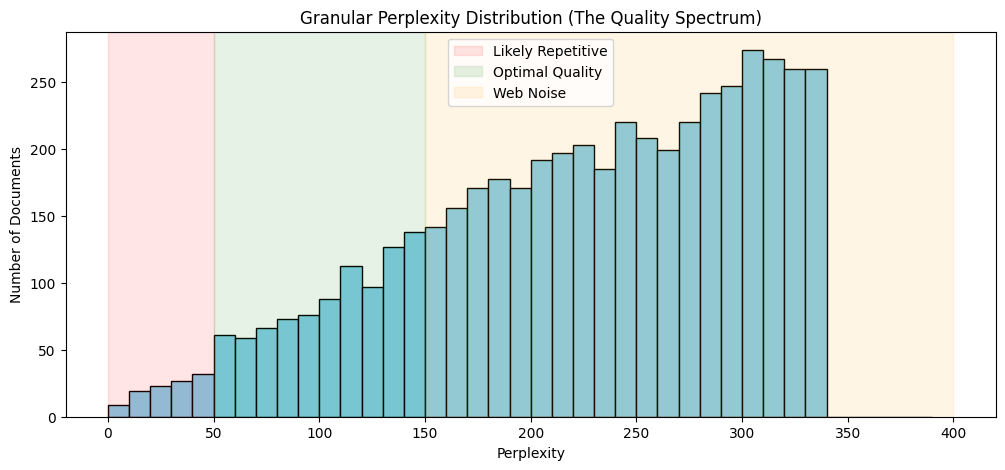


--- Samples of 'Repetitive' Documents (Perplexity < 50) ---
P=45.4 | Content: Welcome to the new academic year 2019/20...
P=40.9 | Content: WYSIWYG. There are 4 heads....
P=35.0 | Content: Created by yo on Oct. 2, 2012, 8 p.m.....


In [29]:
bins = [0, 50, 100, 150, 200, 300, 500]
labels = ['Repetitive/Bot (<50)', 'High Quality (50-100)', 'Good Web (100-150)',
          'Informal (150-200)', 'Noisy Web (200-300)', 'Low Quality (300+)']

p_series = pd.Series(perplexities)
categories = pd.cut(p_series, bins=bins, labels=labels)
counts = categories.value_counts().sort_index()

print("--- Detailed Perplexity Breakdown ---")
for label, count in counts.items():
    percentage = (count / len(perplexities)) * 100
    print(f"{label:25}: {count:5} docs ({percentage:.1f}%)")

plt.figure(figsize=(12, 5))
plt.hist(perplexities, bins=range(0, 400, 10), color="skyblue", edgecolor="black")

plt.axvspan(0, 50, color='red', alpha=0.1, label='Likely Repetitive')
plt.axvspan(50, 150, color='green', alpha=0.1, label='Optimal Quality')
plt.axvspan(150, 400, color='orange', alpha=0.1, label='Web Noise')

plt.title("Granular Perplexity Distribution (The Quality Spectrum)")
plt.xlabel("Perplexity")
plt.ylabel("Number of Documents")
plt.legend()
plt.show()

low_p_indices = [i for i, p in enumerate(perplexities) if p < 50]
if low_p_indices:
    print("\n--- Samples of 'Repetitive' Documents (Perplexity < 50) ---")
    for idx in low_p_indices[:3]:
        print(f"P={perplexities[idx]:.1f} | Content: {dataset[idx]['raw_content'][:150]}...")

Distribucija perpleksnosti pokazuje da većina dokumenata potpada pod opsege noisy veba (42.3%) i niskog kvaliteta (21.2%), što potvrđuje nizak kvalitet ovog skupa podataka. Samo 6.7% dokumenata spada u opseg visokog kvaliteta (50-100). Primetno je da broj dokumenata raste skoro linearno sa povećanjem perpleksnosti — što znači da što je nivo šuma veći, to ima više dokumenata — a to je suprotno od onoga kako bi dobro filtriran korpus trebalo da izgleda.

## ML-based classifiers

Average PALM score:             0.0490
Average WikiRef score:          0.0351
Average Wikipedia importance:   -87.404

Documents with PALM score > 0.1: 472 (9.4%)


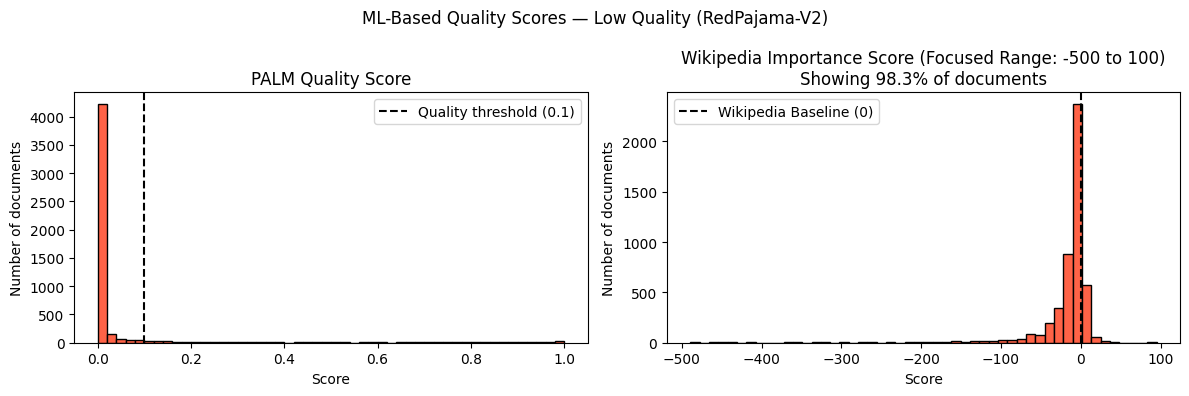

Docs above 0 (Encycopedic): 1016
Docs below -100 (Deep Noise): 285


In [30]:
palm_scores = []
wikiref_scores = []
wikipedia_importance = []

for doc in dataset:
    qs = json.loads(doc["quality_signals"])
    palm = qs["rps_doc_ml_palm_score"][0][2]
    wikiref = qs["rps_doc_ml_wikiref_score"][0][2]
    wiki_imp = qs["rps_doc_wikipedia_importance"][0][2]
    if palm is not None:
        palm_scores.append(palm)
    if wikiref is not None:
        wikiref_scores.append(wikiref)
    if wiki_imp is not None:
        wikipedia_importance.append(wiki_imp)

print(f"Average PALM score:             {np.mean(palm_scores):.4f}")
print(f"Average WikiRef score:          {np.mean(wikiref_scores):.4f}")
print(f"Average Wikipedia importance:   {np.mean(wikipedia_importance):.3f}")
print(f"\nDocuments with PALM score > 0.1: {sum(1 for s in palm_scores if s > 0.1)} ({100*sum(1 for s in palm_scores if s > 0.1)/len(palm_scores):.1f}%)")

focused_wiki_imp = [s for s in wikipedia_importance if -500 <= s <= 100]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(palm_scores, bins=50, color="tomato", edgecolor="black")
axes[0].axvline(0.1, color="black", linestyle="--", label="Quality threshold (0.1)")
axes[0].set_title("PALM Quality Score")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Number of documents")
axes[0].legend()

axes[1].hist(focused_wiki_imp, bins=50, color="tomato", edgecolor="black")
axes[1].axvline(0, color="black", linestyle="--", label="Wikipedia Baseline (0)")
percentage_shown = 100 * len(focused_wiki_imp) / len(wikipedia_importance)
axes[1].set_title(f"Wikipedia Importance Score (Focused Range: -500 to 100)\n"
          f"Showing {percentage_shown:.1f}% of documents")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("Number of documents")
axes[1].legend()


plt.suptitle("ML-Based Quality Scores — Low Quality (RedPajama-V2)")
plt.tight_layout()
plt.show()

print(f"Docs above 0 (Encycopedic): {sum(1 for s in wikipedia_importance if s > 0)}")
print(f"Docs below -100 (Deep Noise): {sum(1 for s in wikipedia_importance if s < -100)}")

Može se primetiti da samo 9.4% dokumenata prelazi prag od 0.1 za PALM skor (koji ukazuje na to koliko je tekst koristan), dok se za ostatak pretpostavlja da su niskog kvaliteta.

Niski WikiRef i Wikipedia Importance skorovi ukazuju na to da dokumenti verovatno nisu citati, naučni radovi, tekstovi sa Vikipedije ili enciklopedijski tekstovi.

Međutim, grafikoni pokazuju da postoji nekoliko primera sa visokim PALM skorovima, kao i 1.016 primeraka sa Wikipedia Importance skorom većim od 0.

## Overal quality

In [31]:
stop_word_fractions = []
mean_word_lengths = []
no_alph_fractions = []

for doc in dataset:
    qs = json.loads(doc["quality_signals"])
    stop_word_fractions.append(qs["rps_doc_stop_word_fraction"][0][2])
    mean_word_lengths.append(qs["rps_doc_mean_word_length"][0][2])
    no_alph_fractions.append(qs["rps_doc_frac_no_alph_words"][0][2])

print("=" * 50)
print("QUALITY SIGNAL SUMMARY — LOW QUALITY DATASET")
print("=" * 50)
print(f"{'Metric':<35} {'Mean':>8} {'Median':>8}")
print("-" * 50)
print(f"{'CCNet Perplexity':<35} {np.mean(perplexities):>8.1f} {np.median(perplexities):>8.1f}")
print(f"{'Stop-word fraction':<35} {np.mean(stop_word_fractions):>8.3f} {np.median(stop_word_fractions):>8.3f}")
print(f"{'Mean word length':<35} {np.mean(mean_word_lengths):>8.3f} {np.median(mean_word_lengths):>8.3f}")
print(f"{'Non-alphabetical fraction':<35} {np.mean(no_alph_fractions):>8.3f} {np.median(no_alph_fractions):>8.3f}")
print(f"{'Unigram entropy':<35} {np.mean(unigram_entropies):>8.3f} {np.median(unigram_entropies):>8.3f}")
print(f"{'PALM score':<35} {np.mean(palm_scores):>8.4f} {np.median(palm_scores) if palm_scores else 0:>8.4f}")
print(f"{'Duplicate fraction (exact)':<35} {total_duplicates/len(dataset):>8.3f} {'N/A':>8}")
print("=" * 50)

QUALITY SIGNAL SUMMARY — LOW QUALITY DATASET
Metric                                  Mean   Median
--------------------------------------------------
CCNet Perplexity                       223.3    234.3
Stop-word fraction                     0.183    0.143
Mean word length                       6.051    4.903
Non-alphabetical fraction              0.359    0.350
Unigram entropy                        2.857    2.928
PALM score                            0.0490  -0.0000
Duplicate fraction (exact)             0.127      N/A


# STEP 7 — Preprocessing Pipeline


In [32]:
import unicodedata
import html
import re
import json
from collections import Counter

# ── Preprocessing functions ──────────────────────────────────────────────────

def normalize_unicode(text):
    """NFC normalization — resolves visually identical characters
    with different code points (C4 standard)."""
    return unicodedata.normalize("NFC", text)

def decode_html_entities(text):
    """Convert &amp; &lt; &nbsp; etc. into their plain-text equivalents."""
    return html.unescape(text)

def normalize_whitespace(text):
    """Collapse multiple spaces/tabs into one, normalize line endings."""
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()

def remove_boilerplate(text):
    """Remove known footer/header boilerplate fragments (RefinedWeb/Gopher)."""
    patterns = [
        r"all rights reserved\.?",
        r"privacy policy\.?",
        r"terms of (service|use)\.?",
        r"cookie(s)?\s+(policy|notice|consent)\.?",
        r"lorem ipsum[^.]*\.",
        r"\bnavigation\b.{0,30}\bmenu\b",
    ]
    for pat in patterns:
        text = re.sub(pat, "", text, flags=re.IGNORECASE)
    return text.strip()

def clean_document(text):
    """Apply the full normalization pipeline to a single document."""
    text = decode_html_entities(text)
    text = normalize_unicode(text)
    text = remove_boilerplate(text)
    text = normalize_whitespace(text)
    return text

# ── Quality filter functions ─────────────────────────────────────────────────

def passes_language_filter(doc, min_score=0.80):
    """Keep only documents with high language identification confidence."""
    qs = json.loads(doc["quality_signals"])
    return qs["ccnet_language_score"][0][2] >= min_score

def passes_deduplication_filter(doc):
    """Remove exact duplicates flagged by RedPajama."""
    qs = json.loads(doc["quality_signals"])
    return not qs["is_duplicate"]

def passes_palm_filter(doc, min_score=0.05):
    """Keep documents that pass the minimum ML quality threshold."""
    qs = json.loads(doc["quality_signals"])
    palm = qs["rps_doc_ml_palm_score"][0][2]
    if palm is None:
        return True  # if signal missing, don't discard
    return palm >= min_score

def passes_repetitiveness_filter(doc, max_dupe_5gram=0.30):
    """Remove highly repetitive documents (RefinedWeb standard)."""
    qs = json.loads(doc["quality_signals"])
    return qs["rps_doc_frac_chars_dupe_5grams"][0][2] <= max_dupe_5gram

def passes_min_length_filter(text, min_words=30):
    """Require at least min_words after cleaning."""
    return len(text.split()) >= min_words

# ── Apply pipeline ───────────────────────────────────────────────────────────

print("Applying preprocessing pipeline to baseline dataset...")
print(f"Starting documents: {len(dataset)}")

cleaned_dataset = []
rejection_reasons = Counter()

for doc in dataset:
    # Step 1: Exact deduplication
    if not passes_deduplication_filter(doc):
        rejection_reasons["exact duplicate"] += 1
        continue

    # Step 2: Language confidence
    if not passes_language_filter(doc):
        rejection_reasons["low language confidence"] += 1
        continue

    # Step 3: PALM quality score
    if not passes_palm_filter(doc):
        rejection_reasons["low PALM score"] += 1
        continue

    # Step 4: Repetitiveness filter
    if not passes_repetitiveness_filter(doc):
        rejection_reasons["high repetitiveness"] += 1
        continue

    # Step 5: Text normalization
    cleaned_text = clean_document(doc["raw_content"])

    # Step 6: Minimum length after cleaning
    if not passes_min_length_filter(cleaned_text):
        rejection_reasons["too short after cleaning"] += 1
        continue

    # Build cleaned document
    cleaned_doc = dict(doc)
    cleaned_doc["raw_content"] = cleaned_text
    cleaned_dataset.append(cleaned_doc)

print(f"Documents after preprocessing: {len(cleaned_dataset)}")
print(f"Removed: {len(dataset) - len(cleaned_dataset)} documents ({100*(len(dataset)-len(cleaned_dataset))/len(dataset):.1f}%)")
print()
print("Rejection breakdown:")
for reason, count in rejection_reasons.most_common():
    print(f"  {reason}: {count} ({100*count/len(dataset):.1f}%)")


Applying preprocessing pipeline to baseline dataset...
Starting documents: 5000
Documents after preprocessing: 274
Removed: 4726 documents (94.5%)

Rejection breakdown:
  low PALM score: 2270 (45.4%)
  low language confidence: 1694 (33.9%)
  exact duplicate: 636 (12.7%)
  too short after cleaning: 116 (2.3%)
  high repetitiveness: 10 (0.2%)


# STEP 8 — Post-Preprocessing Analysis


## 8.1 Document Length

=== POST-PREPROCESSING DOCUMENT LENGTH ===
Total documents: 274
Average length:  8939 characters
Median length:   240 characters
Shortest: 143 characters
Longest:  958956 characters

Documents under 100 chars:  0
Documents over 100k chars:  3


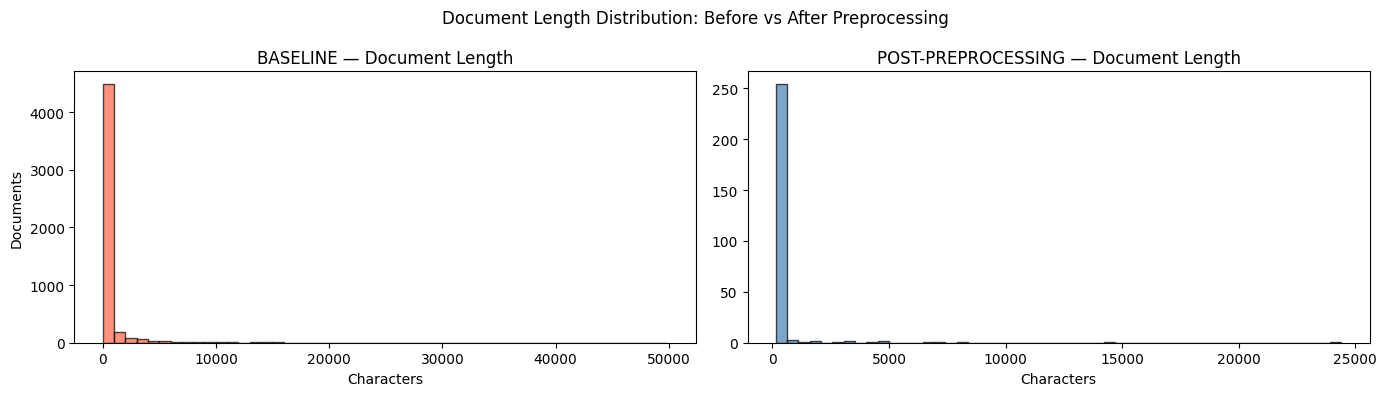

In [33]:
import statistics

c_lengths = [len(doc["raw_content"]) for doc in cleaned_dataset]

print("=== POST-PREPROCESSING DOCUMENT LENGTH ===")
print(f"Total documents: {len(c_lengths)}")
print(f"Average length:  {sum(c_lengths)/len(c_lengths):.0f} characters")
print(f"Median length:   {statistics.median(c_lengths):.0f} characters")
print(f"Shortest: {min(c_lengths)} characters")
print(f"Longest:  {max(c_lengths)} characters")
print(f"\nDocuments under 100 chars:  {sum(1 for l in c_lengths if l < 100)}")
print(f"Documents over 100k chars:  {sum(1 for l in c_lengths if l > 100_000)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

baseline_lengths = [len(doc["raw_content"]) for doc in dataset]
axes[0].hist([l for l in baseline_lengths if l < 50_000], bins=50,
             color="tomato", edgecolor="black", alpha=0.7)
axes[0].set_title("BASELINE — Document Length")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Documents")

axes[1].hist([l for l in c_lengths if l < 50_000], bins=50,
             color="steelblue", edgecolor="black", alpha=0.7)
axes[1].set_title("POST-PREPROCESSING — Document Length")
axes[1].set_xlabel("Characters")

plt.suptitle("Document Length Distribution: Before vs After Preprocessing")
plt.tight_layout()
plt.show()


## 8.2 Lexical Analysis — TTR and Zipf's Law

=== TTR COMPARISON ===
Metric                                  Baseline   Preprocessed
--------------------------------------------------------------
Average per-document TTR                   0.828          0.798
Median per-document TTR                    0.875          0.824
Total tokens                           1,023,351        390,795
Unique tokens                            113,034         31,398
Global TTR                                 0.110          0.080


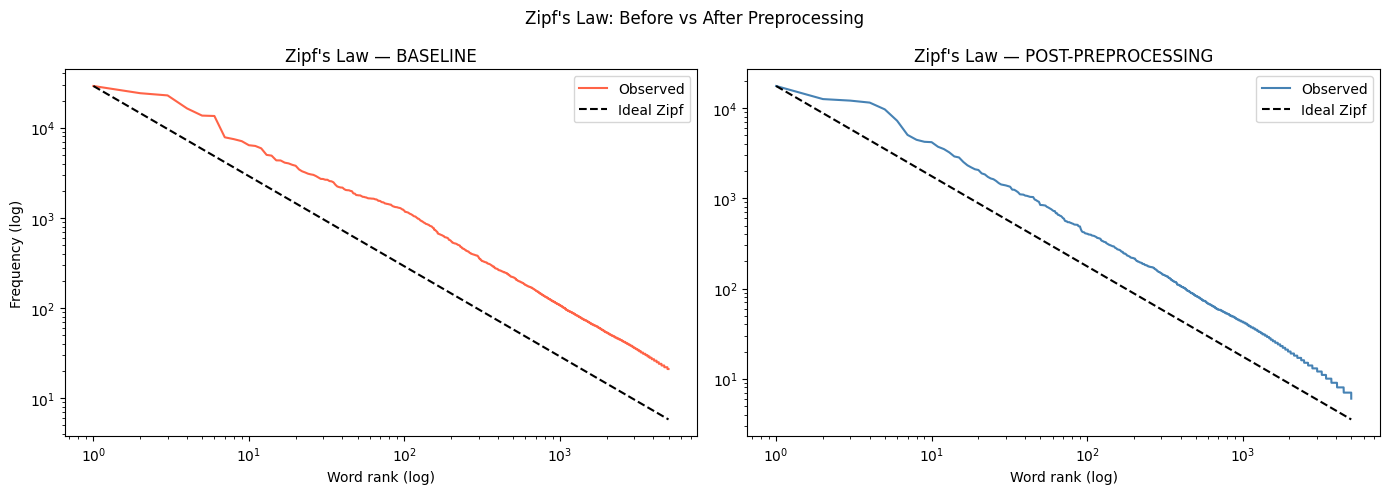

In [34]:
# TTR on cleaned dataset
c_ttr_scores = []
for doc in cleaned_dataset:
    words = doc["raw_content"].lower().split()
    if len(words) == 0:
        continue
    c_ttr_scores.append(len(set(words)) / len(words))

# Vocabulary
c_all_words = []
for doc in cleaned_dataset:
    c_all_words.extend(doc["raw_content"].lower().split())
c_word_counts = Counter(c_all_words)

print("=== TTR COMPARISON ===")
print(f"{'Metric':<35} {'Baseline':>12} {'Preprocessed':>14}")
print("-" * 62)
print(f"{'Average per-document TTR':<35} {np.mean(ttr_scores):>12.3f} {np.mean(c_ttr_scores):>14.3f}")
print(f"{'Median per-document TTR':<35} {np.median(ttr_scores):>12.3f} {np.median(c_ttr_scores):>14.3f}")
print(f"{'Total tokens':<35} {len(all_words):>12,} {len(c_all_words):>14,}")
print(f"{'Unique tokens':<35} {len(word_counts):>12,} {len(c_word_counts):>14,}")
print(f"{'Global TTR':<35} {len(word_counts)/len(all_words):>12.3f} {len(c_word_counts)/len(c_all_words):>14.3f}")

# Zipf comparison
c_frequencies = sorted(c_word_counts.values(), reverse=True)
c_ranks = range(1, len(c_frequencies) + 1)
top_n = 5000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].loglog(list(ranks)[:top_n], frequencies[:top_n], color="tomato", label="Observed")
axes[0].loglog(list(ranks)[:top_n], [frequencies[0]/r for r in list(ranks)[:top_n]],
               color="black", linestyle="--", label="Ideal Zipf")
axes[0].set_title("Zipf's Law — BASELINE")
axes[0].set_xlabel("Word rank (log)")
axes[0].set_ylabel("Frequency (log)")
axes[0].legend()

axes[1].loglog(list(c_ranks)[:top_n], c_frequencies[:top_n], color="steelblue", label="Observed")
axes[1].loglog(list(c_ranks)[:top_n], [c_frequencies[0]/r for r in list(c_ranks)[:top_n]],
               color="black", linestyle="--", label="Ideal Zipf")
axes[1].set_title("Zipf's Law — POST-PREPROCESSING")
axes[1].set_xlabel("Word rank (log)")
axes[1].legend()

plt.suptitle("Zipf\'s Law: Before vs After Preprocessing")
plt.tight_layout()
plt.show()


## 8.3 Unigram Entropy

=== UNIGRAM ENTROPY COMPARISON ===
Metric                                  Baseline   Preprocessed
--------------------------------------------------------------
Average unigram entropy                    2.857          3.505
Median unigram entropy                     2.928          3.409
Average word count                         201.8         1424.2
Median word count                           25.0           41.0


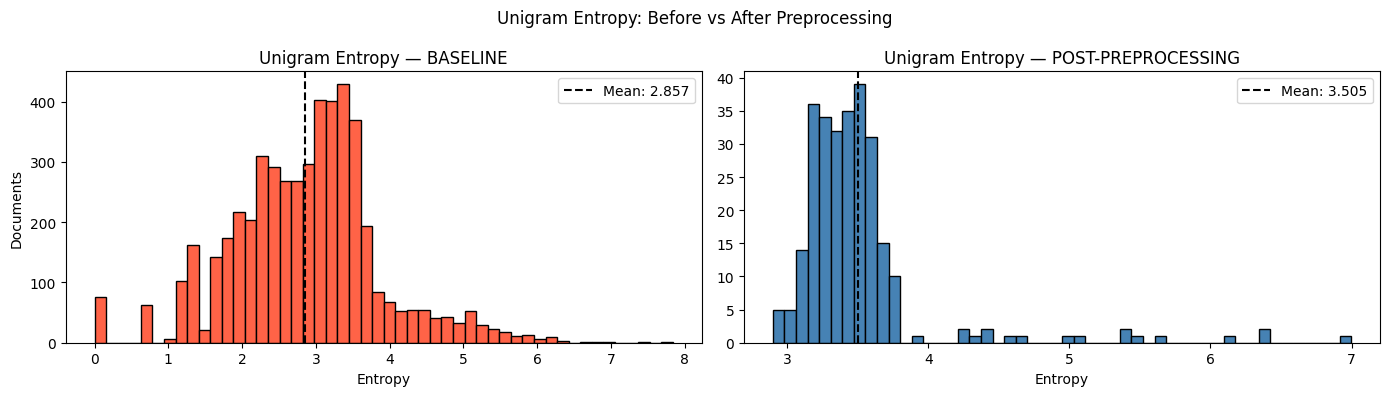

In [35]:
# Unigram entropy on cleaned dataset
c_unigram_entropies = []
c_word_counts_qs = []

for doc in cleaned_dataset:
    qs = json.loads(doc["quality_signals"])
    c_unigram_entropies.append(qs["rps_doc_unigram_entropy"][0][2])
    c_word_counts_qs.append(qs["rps_doc_word_count"][0][2])

print("=== UNIGRAM ENTROPY COMPARISON ===")
print(f"{'Metric':<35} {'Baseline':>12} {'Preprocessed':>14}")
print("-" * 62)
print(f"{'Average unigram entropy':<35} {np.mean(unigram_entropies):>12.3f} {np.mean(c_unigram_entropies):>14.3f}")
print(f"{'Median unigram entropy':<35} {np.median(unigram_entropies):>12.3f} {np.median(c_unigram_entropies):>14.3f}")
print(f"{'Average word count':<35} {np.mean(word_counts_qs):>12.1f} {np.mean(c_word_counts_qs):>14.1f}")
print(f"{'Median word count':<35} {np.median(word_counts_qs):>12.1f} {np.median(c_word_counts_qs):>14.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(unigram_entropies, bins=50, color="tomato", edgecolor="black")
axes[0].axvline(np.mean(unigram_entropies), color="black", linestyle="--",
                label=f"Mean: {np.mean(unigram_entropies):.3f}")
axes[0].set_title("Unigram Entropy — BASELINE")
axes[0].set_xlabel("Entropy")
axes[0].set_ylabel("Documents")
axes[0].legend()

axes[1].hist(c_unigram_entropies, bins=50, color="steelblue", edgecolor="black")
axes[1].axvline(np.mean(c_unigram_entropies), color="black", linestyle="--",
                label=f"Mean: {np.mean(c_unigram_entropies):.3f}")
axes[1].set_title("Unigram Entropy — POST-PREPROCESSING")
axes[1].set_xlabel("Entropy")
axes[1].legend()

plt.suptitle("Unigram Entropy: Before vs After Preprocessing")
plt.tight_layout()
plt.show()


## 8.4 Noise Detection

In [36]:
# Noise metrics on cleaned dataset
c_symbol_ratios = []
c_no_alph_fractions = []
c_dupe_5gram = []
c_dupe_10gram = []

for doc in cleaned_dataset:
    qs = json.loads(doc["quality_signals"])
    c_symbol_ratios.append(qs["rps_doc_symbol_to_word_ratio"][0][2])
    c_no_alph_fractions.append(qs["rps_doc_frac_no_alph_words"][0][2])
    c_dupe_5gram.append(qs["rps_doc_frac_chars_dupe_5grams"][0][2])
    c_dupe_10gram.append(qs["rps_doc_frac_chars_dupe_10grams"][0][2])

print("=== NOISE METRICS COMPARISON ===")
print(f"{'Metric':<40} {'Baseline':>12} {'Preprocessed':>14}")
print("-" * 67)
print(f"{'Avg symbol-to-word ratio':<40} {np.mean(symbol_ratios):>12.3f} {np.mean(c_symbol_ratios):>14.3f}")
print(f"{'Avg non-alphabetical fraction':<40} {np.mean(no_alph_fractions):>12.3f} {np.mean(c_no_alph_fractions):>14.3f}")
print(f"{'Avg dupe 5-gram fraction':<40} {np.mean(dupe_5gram):>12.3f} {np.mean(c_dupe_5gram):>14.3f}")
print(f"{'Avg dupe 10-gram fraction':<40} {np.mean(dupe_10gram):>12.3f} {np.mean(c_dupe_10gram):>14.3f}")
print(f"{'Docs with dupe 5-grams > 0.1':<40} {sum(1 for x in dupe_5gram if x>0.1):>12} {sum(1 for x in c_dupe_5gram if x>0.1):>14}")

# Boilerplate re-check on cleaned data
boilerplate_patterns_check = {
    "all rights reserved": re.compile(r'all rights reserved', re.IGNORECASE),
    "privacy policy": re.compile(r'privacy policy', re.IGNORECASE),
    "terms of service": re.compile(r'terms of (service|use)', re.IGNORECASE),
    "lorem ipsum": re.compile(r'lorem ipsum', re.IGNORECASE),
}
print("\n=== BOILERPLATE AFTER PREPROCESSING ===")
for name, pat in boilerplate_patterns_check.items():
    count = sum(1 for doc in cleaned_dataset if pat.search(doc["raw_content"]))
    print(f"  {name}: {count} documents ({100*count/len(cleaned_dataset):.1f}%)")


=== NOISE METRICS COMPARISON ===
Metric                                       Baseline   Preprocessed
-------------------------------------------------------------------
Avg symbol-to-word ratio                        0.006          0.010
Avg non-alphabetical fraction                   0.359          0.182
Avg dupe 5-gram fraction                        0.058          0.012
Avg dupe 10-gram fraction                       0.017          0.002
Docs with dupe 5-grams > 0.1                      663             15

=== BOILERPLATE AFTER PREPROCESSING ===
  all rights reserved: 0 documents (0.0%)
  privacy policy: 0 documents (0.0%)
  terms of service: 0 documents (0.0%)
  lorem ipsum: 0 documents (0.0%)


## 8.5 Deduplication

In [37]:
# Deduplication on cleaned dataset
c_duplicate_flags = []
for doc in cleaned_dataset:
    qs = json.loads(doc["quality_signals"])
    c_duplicate_flags.append(qs["is_duplicate"])

c_total_duplicates = sum(c_duplicate_flags)
print("=== DEDUPLICATION COMPARISON ===")
print(f"{'Metric':<40} {'Baseline':>12} {'Preprocessed':>14}")
print("-" * 67)
print(f"{'Total documents':<40} {len(dataset):>12} {len(cleaned_dataset):>14}")
print(f"{'Exact duplicates':<40} {total_duplicates:>12} {c_total_duplicates:>14}")
print(f"{'Duplicate rate':<40} {100*total_duplicates/len(dataset):>11.1f}% {100*c_total_duplicates/len(cleaned_dataset):>13.1f}%")


=== DEDUPLICATION COMPARISON ===
Metric                                       Baseline   Preprocessed
-------------------------------------------------------------------
Total documents                                  5000            274
Exact duplicates                                  636              0
Duplicate rate                                  12.7%           0.0%


## 8.6 Quality Signal Summary — Before vs After

QUALITY SIGNAL SUMMARY — BASELINE vs POST-PREPROCESSING
Metric                               Baseline Mean   Cleaned Mean
-------------------------------------------------------------------
CCNet Perplexity                             223.3          227.4
Stop-word fraction                           0.183          0.354
Mean word length                             6.051          4.903
Non-alphabetical fraction                    0.359          0.182
Unigram entropy                              2.857          3.505
PALM score                                  0.0490         0.4137
Duplicate fraction                           0.127          0.000
Documents retained                            5000            274


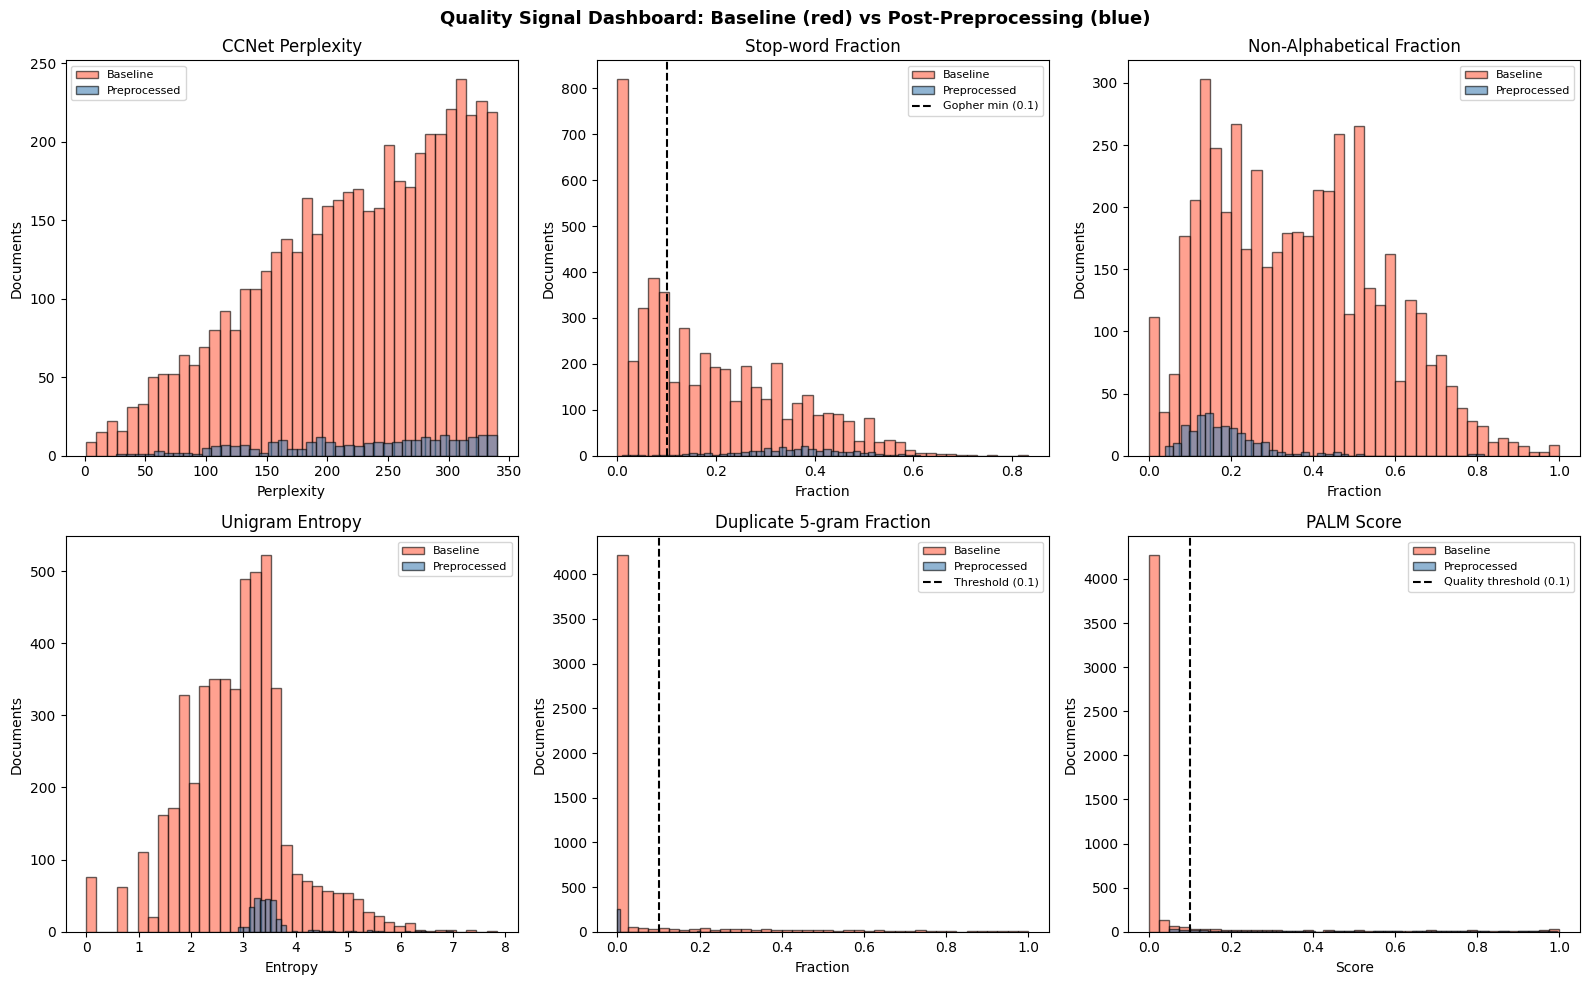

In [38]:
# Re-collect quality signals on cleaned dataset
c_stop_word_fractions = []
c_mean_word_lengths = []
c_no_alph_fr = []
c_palm_scores = []
c_perplexities = []

for doc in cleaned_dataset:
    qs = json.loads(doc["quality_signals"])
    c_stop_word_fractions.append(qs["rps_doc_stop_word_fraction"][0][2])
    c_mean_word_lengths.append(qs["rps_doc_mean_word_length"][0][2])
    c_no_alph_fr.append(qs["rps_doc_frac_no_alph_words"][0][2])
    c_perplexities.append(qs["ccnet_perplexity"][0][2])
    palm = qs["rps_doc_ml_palm_score"][0][2]
    if palm is not None:
        c_palm_scores.append(palm)

print("=" * 67)
print("QUALITY SIGNAL SUMMARY — BASELINE vs POST-PREPROCESSING")
print("=" * 67)
print(f"{'Metric':<35} {'Baseline Mean':>14} {'Cleaned Mean':>14}")
print("-" * 67)
print(f"{'CCNet Perplexity':<35} {np.mean(perplexities):>14.1f} {np.mean(c_perplexities):>14.1f}")
print(f"{'Stop-word fraction':<35} {np.mean(stop_word_fractions):>14.3f} {np.mean(c_stop_word_fractions):>14.3f}")
print(f"{'Mean word length':<35} {np.mean(mean_word_lengths):>14.3f} {np.mean(c_mean_word_lengths):>14.3f}")
print(f"{'Non-alphabetical fraction':<35} {np.mean(no_alph_fractions):>14.3f} {np.mean(c_no_alph_fr):>14.3f}")
print(f"{'Unigram entropy':<35} {np.mean(unigram_entropies):>14.3f} {np.mean(c_unigram_entropies):>14.3f}")
print(f"{'PALM score':<35} {np.mean(palm_scores):>14.4f} {np.mean(c_palm_scores):>14.4f}")
print(f"{'Duplicate fraction':<35} {total_duplicates/len(dataset):>14.3f} {c_total_duplicates/len(cleaned_dataset):>14.3f}")
print(f"{'Documents retained':<35} {len(dataset):>14} {len(cleaned_dataset):>14}")
print("=" * 67)

# Dashboard comparison
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

def compare_hist(ax, baseline, cleaned, title, xlabel, threshold=None, threshold_label=None):
    ax.hist(baseline, bins=40, color="tomato", edgecolor="black", alpha=0.6, label="Baseline")
    ax.hist(cleaned,  bins=40, color="steelblue", edgecolor="black", alpha=0.6, label="Preprocessed")
    if threshold:
        ax.axvline(threshold, color="black", linestyle="--", label=threshold_label)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Documents")
    ax.legend(fontsize=8)

compare_hist(axes[0][0], [p for p in perplexities if p<500],
             [p for p in c_perplexities if p<500],
             "CCNet Perplexity", "Perplexity")

compare_hist(axes[0][1], stop_word_fractions, c_stop_word_fractions,
             "Stop-word Fraction", "Fraction",
             threshold=0.1, threshold_label="Gopher min (0.1)")

compare_hist(axes[0][2], no_alph_fractions, c_no_alph_fr,
             "Non-Alphabetical Fraction", "Fraction")

compare_hist(axes[1][0], unigram_entropies, c_unigram_entropies,
             "Unigram Entropy", "Entropy")

compare_hist(axes[1][1], dupe_5gram, c_dupe_5gram,
             "Duplicate 5-gram Fraction", "Fraction",
             threshold=0.1, threshold_label="Threshold (0.1)")

compare_hist(axes[1][2], palm_scores, c_palm_scores,
             "PALM Score", "Score",
             threshold=0.1, threshold_label="Quality threshold (0.1)")

plt.suptitle("Quality Signal Dashboard: Baseline (red) vs Post-Preprocessing (blue)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


Primetno je da su neki aspekti šuma očišćeni i da je kvalitet poboljšan – duplikati (0%), n-grami, generički tekstovi (boilerplate), segmenti koji sadrze ne-alfabetske znake, veća unigramska entropija,veći broj i dužina reči, (blago) bolji grafik Zipfovog zakona i znatno veći PALM skor.

Niži TTR (Type-Token Ratio) nakon pretprocesiranja je očekivan i poželjan. Osnovni TTR bio je veštački uvećan zbog hiljada veoma kratkih dokumenata (medijan 25 reči). Nakon pretprocesiranja, dokumenti su duži (medijan broja reči 25 → 41, prosek 201 → 1424), pa TTR prirodno opada jer se reči koje se ponavljaju akumuliraju kroz duže tekstove. Pad globalnog TTR-a sa 0.110 na 0.080 uz znatno manji broj dokumenata (274 naspram 5000), dok set sadrži 390 hiljada tokena, zapravo je znak bogatijih i dužih dokumenata — a ne siromašnijeg rečnika.

Međutim, sa druge strane, postoji veliki nedostatak – značajno smanjenje broja dokumenata (94,5%). Ovo ne bi bilo toliko problematično da skup podataka sadrži milione dokumenata, ali ovde nam je ostalo svega 274 dokumenta, što nije dovoljno za treniranje ili fino podešavanje (fine-tuning) velikog jezičkog modela.

---------------------------

# UP - SAMPLING

Zbog malog broja dokumenata koji su prošli proces pretprocesiranja, pokušaću da snizim PALM prag (threshold), pošto je on bio razlog zašto je većina dokumenata odbačena.

In [39]:
def passes_palm_filter(doc, min_score=0.01):
    """Keep documents that pass the minimum ML quality threshold."""
    qs = json.loads(doc["quality_signals"])
    palm = qs["rps_doc_ml_palm_score"][0][2]
    if palm is None:
        return True  # if signal missing, don't discard
    return palm >= min_score

def passes_language_filter(doc, min_score=0.70):
    """Keep only documents with high language identification confidence."""
    qs = json.loads(doc["quality_signals"])
    return qs["ccnet_language_score"][0][2] >= min_score

# ── Apply pipeline ───────────────────────────────────────────────────────────

print("Applying preprocessing pipeline to baseline dataset...")
print(f"Starting documents: {len(dataset)}")

cleaned_dataset = []
rejection_reasons = Counter()

for doc in dataset:
    # Step 1: Exact deduplication
    if not passes_deduplication_filter(doc):
        rejection_reasons["exact duplicate"] += 1
        continue

    # Step 2: Language confidence
    if not passes_language_filter(doc):
        rejection_reasons["low language confidence"] += 1
        continue

    # Step 3: PALM quality score
    if not passes_palm_filter(doc):
        rejection_reasons["low PALM score"] += 1
        continue

    # Step 4: Repetitiveness filter
    if not passes_repetitiveness_filter(doc):
        rejection_reasons["high repetitiveness"] += 1
        continue

    # Step 5: Text normalization
    cleaned_text = clean_document(doc["raw_content"])

    # Step 6: Minimum length after cleaning
    if not passes_min_length_filter(cleaned_text):
        rejection_reasons["too short after cleaning"] += 1
        continue

    # Build cleaned document
    cleaned_doc = dict(doc)
    cleaned_doc["raw_content"] = cleaned_text
    cleaned_dataset.append(cleaned_doc)

print(f"Documents after preprocessing: {len(cleaned_dataset)}")
print(f"Removed: {len(dataset) - len(cleaned_dataset)} documents ({100*(len(dataset)-len(cleaned_dataset))/len(dataset):.1f}%)")
print()
print("Rejection breakdown:")
for reason, count in rejection_reasons.most_common():
    print(f"  {reason}: {count} ({100*count/len(dataset):.1f}%)")


Applying preprocessing pipeline to baseline dataset...
Starting documents: 5000
Documents after preprocessing: 459
Removed: 4541 documents (90.8%)

Rejection breakdown:
  low PALM score: 2638 (52.8%)
  low language confidence: 1034 (20.7%)
  exact duplicate: 636 (12.7%)
  too short after cleaning: 201 (4.0%)
  high repetitiveness: 32 (0.6%)


-------------

Pošto je količina podataka i dalje mala (459), uradiću Back-Translation. Budući da to zahteva GPU, prvo ću eksportovati podatke, a zatim ih importovati i koristiti u novom notebook-u steps9-11_modified, koristeći Colab.

In [ ]:
import json
from pathlib import Path

export_path = Path("cleaned_dataset_backtranslation_export.jsonl")

with export_path.open("w", encoding="utf-8") as f:
    for row in cleaned_dataset:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

print(f"Exported {len(cleaned_dataset)} documents to {export_path.resolve()}")
